# Task 3.2 — Failure Case Analysis

**Paper**:
 Efficient Variable Selection in Support Vector Machines via the Alternating Direction Method of Multipliers
(ICML 2011)

---

# Introduction

Even strong machine learning models make mistakes.

In this section we analyze cases where the sparse SVM model misclassifies samples.
Understanding these errors helps identify limitations of the model.

---

# Import Libraries

In [11]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

---

# Dataset Preparation

In [12]:
data = load_breast_cancer()

X = data.data
y = data.target

---

# Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

---

# Feature Scaling

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

---

# Train Sparse SVM

In [15]:
model = LinearSVC(
    penalty="l1",
    dual=False,
    max_iter=5000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

---

# Identify Misclassified Samples

In [16]:
misclassified = X_test[y_test != y_pred]

print("Number of misclassified samples:", len(misclassified))

error_rate = np.mean(y_test != y_pred)

print("Error rate:", error_rate)

Number of misclassified samples: 3
Error rate: 0.02631578947368421


In [17]:
mis_idx = np.where(y_test != y_pred)[0]

print("Indices of misclassified samples:")
print(mis_idx[:5])

print("True labels:", y_test[mis_idx[:5]])
print("Predicted labels:", y_pred[mis_idx[:5]])

Indices of misclassified samples:
[16 53 76]
True labels: [1 0 0]
Predicted labels: [0 1 1]


---

# Visualize Prediction Errors

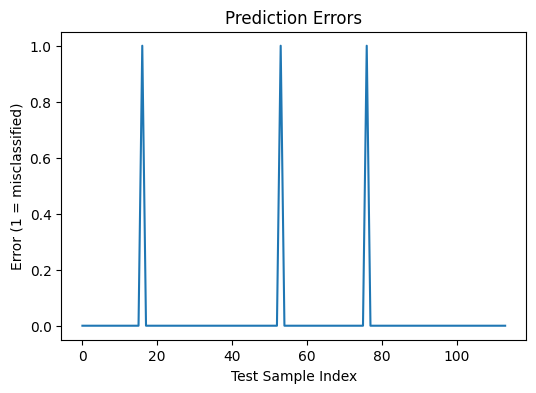

In [18]:
errors = (y_test != y_pred)

plt.figure(figsize=(6,4))

plt.plot(errors.astype(int))

plt.title("Prediction Errors")
plt.xlabel("Test Sample Index")
plt.ylabel("Error (1 = misclassified)")

plt.show()

---

# Discussion

The misclassified samples indicate situations where the sparse SVM model fails to correctly separate the classes.

Possible reasons include:

• Overlapping feature distributions between malignant and benign tumors  
• Noise or measurement variability in the dataset  
• Limitations of a linear decision boundary  

Although sparse SVM models perform feature selection effectively, they may still struggle when the underlying data distribution is complex or when informative features overlap across classes.